# Deep Learning Lite (MNIST & Fashion-MNIST)
Notebook ini dibuat untuk sesi practice: **lihat data → bangun model → AI belajar → evaluasi → test model → level up → mini challenge**.


## Setup & Import
Jalankan sel ini dulu untuk memastikan TensorFlow siap dipakai.

In [1]:
# Setup & Import
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Load Dataset MNIST
MNIST = 70.000 gambar angka tulisan tangan (0–9), ukuran 28×28 pixel.

In [2]:
# Load MNIST (angka tulisan tangan)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape :", x_test.shape, y_test.shape)
print("Contoh label pertama:", y_train[0])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) (60000,)
Test shape : (10000, 28, 28) (10000,)
Contoh label pertama: 5


## Visualisasi Data
Biar kebayang: data = gambar pixel, bukan teks/aturan.

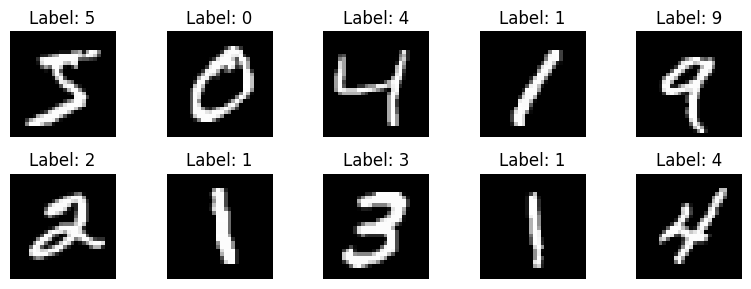

In [3]:
# Visualisasi
plt.figure(figsize=(8, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## Normalisasi
Ubah pixel 0–255 jadi 0–1 agar training lebih stabil dan cepat.

In [4]:
# Normalisasi: bikin angka pixel jadi 0..1
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Min/Max pixel setelah normalisasi:", x_train.min(), x_train.max())


Min/Max pixel setelah normalisasi: 0.0 1.0


## Build Model (Neural Network)
Arsitektur sederhana:
- Flatten (28×28 → 784)
- Dense 128 (ReLU)
- Dense 64 (ReLU)
- Dense 10 (Softmax)

In [5]:
# Build Model: "stack otak"
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Compile Model
- Optimizer: **Adam** (cara update weight)
- Loss: **sparse_categorical_crossentropy** (buat label 0–9)
- Metric: **accuracy**

In [6]:
# Compile: "ngasih aturan cara belajar"
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## Train Model (AI 'Sekolah')
Epoch = berapa kali model melihat semua data training.
Validation split = 20% data dipakai untuk cek generalisasi saat training.

In [7]:
# Train: momen "AI sekolah"
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9234 - loss: 0.2626 - val_accuracy: 0.9568 - val_loss: 0.1430
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9674 - loss: 0.1077 - val_accuracy: 0.9697 - val_loss: 0.0984
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9776 - loss: 0.0730 - val_accuracy: 0.9706 - val_loss: 0.1015
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0549 - val_accuracy: 0.9734 - val_loss: 0.0895
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9852 - loss: 0.0446 - val_accuracy: 0.9742 - val_loss: 0.0974


## Plot Progress
lihat: akurasi naik, loss turun.

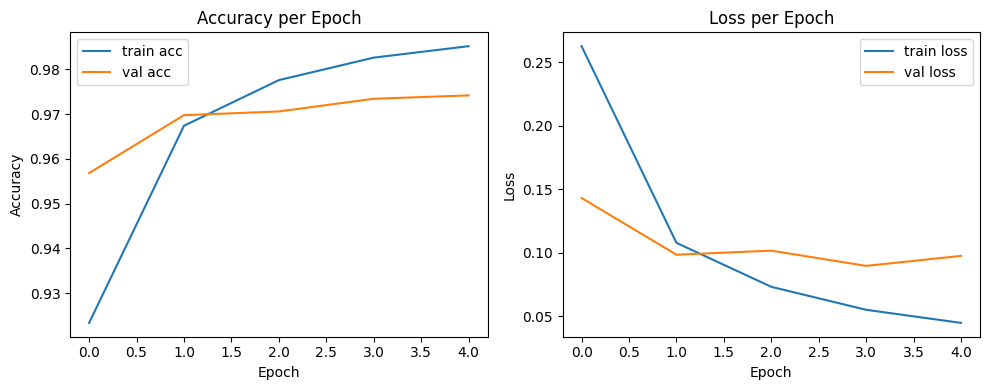

In [8]:
# Plot hasil training
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## Evaluate (Ujian Akhir)
Tes pakai data yang belum pernah dilihat model.

In [9]:
# Evaluate di test set: "ujian akhir"
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")


Test accuracy: 0.9739 | Test loss: 0.0899


## Momen AI Menebak Gambar
Tampilkan 12 gambar + prediksi vs label asli.

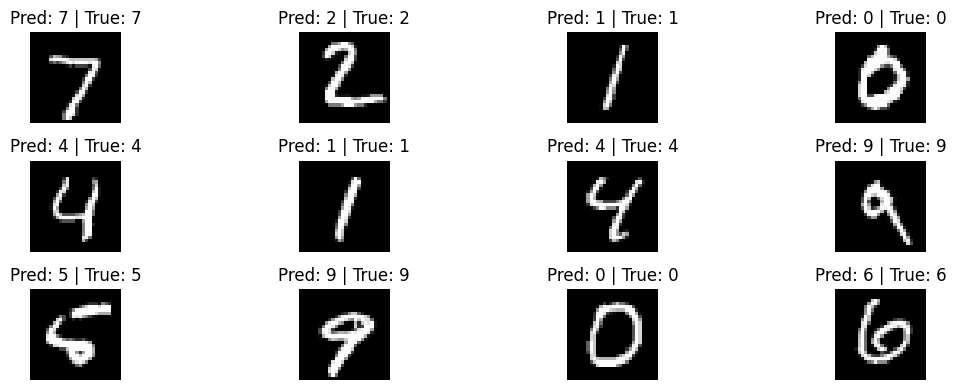

In [10]:
# Momen AI nebak 12 gambar pertama
pred_probs = model.predict(x_test[:12], verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(12, 4))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_test[i], cmap="gray")
    title = f"Pred: {pred_labels[i]} | True: {y_test[i]}"
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()


## AI Bisa Salah (Dan Itu Menarik)

Jumlah salah: 261


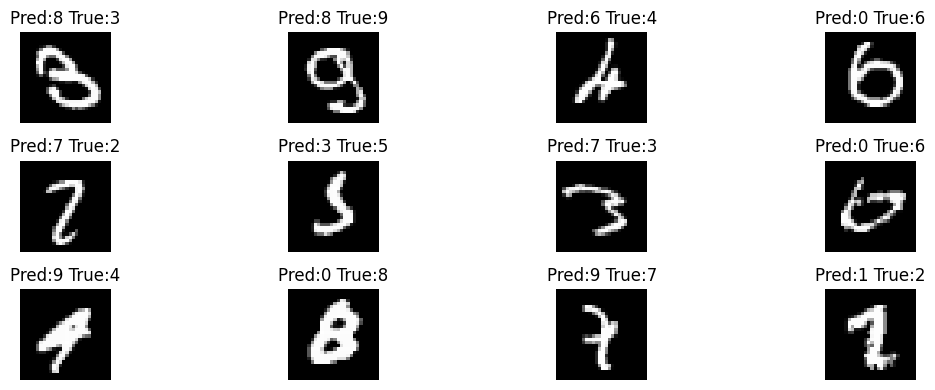

In [11]:
# "AI juga bisa salah"
pred_probs_all = model.predict(x_test, verbose=0)
pred_all = np.argmax(pred_probs_all, axis=1)

wrong_idx = np.where(pred_all != y_test)[0]
print("Jumlah salah:", len(wrong_idx))

# tampilkan 12 contoh salah
plt.figure(figsize=(12, 4))
for j, idx in enumerate(wrong_idx[:12]):
    plt.subplot(3, 4, j+1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(f"Pred:{pred_all[idx]} True:{y_test[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# Level Up: Fashion-MNIST
Dataset pakaian (10 kelas) biasanya lebih sulit daripada MNIST karena bedanya lebih subtle.

## Load Fashion-MNIST + Visualisasi

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


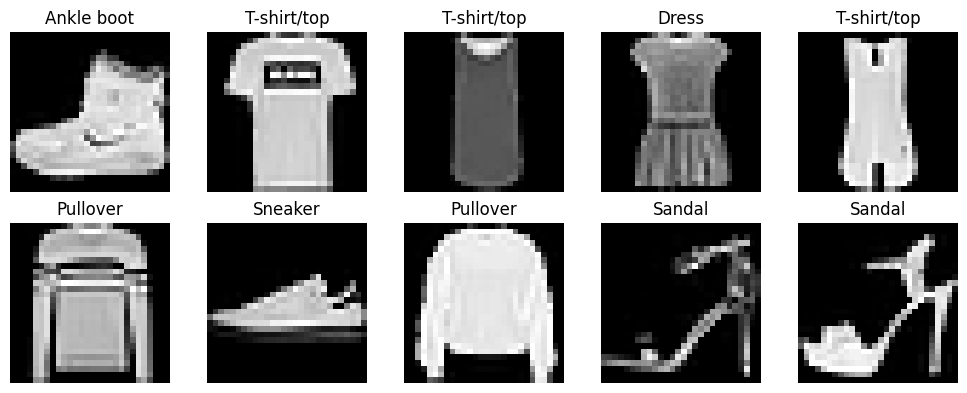

In [12]:
# Load Fashion-MNIST
(fx_train, fy_train), (fx_test, fy_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fx_train = fx_train.astype("float32") / 255.0
fx_test  = fx_test.astype("float32") / 255.0

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(fx_train[i], cmap="gray")
    plt.title(class_names[fy_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


## Train Model untuk Fashion-MNIST
Gunakan arsitektur yang sama untuk menunjukkan konsepnya universal.

In [13]:
# Model yang sama untuk Fashion
fashion_model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

fashion_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fashion_history = fashion_model.fit(
    fx_train, fy_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

fashion_loss, fashion_acc = fashion_model.evaluate(fx_test, fy_test, verbose=0)
print(f"Fashion Test accuracy: {fashion_acc:.4f}")


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8183 - loss: 0.5129 - val_accuracy: 0.8505 - val_loss: 0.4044
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8609 - loss: 0.3813 - val_accuracy: 0.8630 - val_loss: 0.3846
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8732 - loss: 0.3426 - val_accuracy: 0.8622 - val_loss: 0.3805
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8832 - loss: 0.3157 - val_accuracy: 0.8771 - val_loss: 0.3406
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8903 - loss: 0.2986 - val_accuracy: 0.8800 - val_loss: 0.3463
Fashion Test accuracy: 0.8730


## Prediksi Fashion + Nama Kelas
Biar lebih ‘nyambung’ daripada angka.

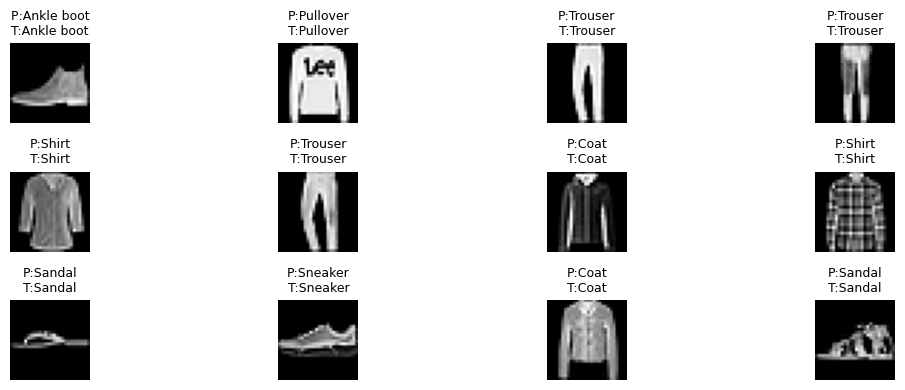

In [14]:
# Prediksi Fashion + tampil nama kelas
fp = fashion_model.predict(fx_test[:12], verbose=0)
flabels = np.argmax(fp, axis=1)

plt.figure(figsize=(12, 4))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(fx_test[i], cmap="gray")
    pred_name = class_names[flabels[i]]
    true_name = class_names[fy_test[i]]
    plt.title(f"P:{pred_name}\nT:{true_name}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()



# Mini Challenge (Eksperimen Hyperparameter)
Jalankan salah satu (atau semuanya) untuk lihat efeknya.

## Challenge 1: Tambah Neuron (128 → 256)

In [15]:
# Challenge 1: tambah neuron
bigger_model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation="relu"),   # dari 128 -> 256
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

bigger_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
bigger_model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=1)

loss, acc = bigger_model.evaluate(x_test, y_test, verbose=0)
print(f"Bigger model test accuracy: {acc:.4f}")


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9288 - loss: 0.2392 - val_accuracy: 0.9593 - val_loss: 0.1344
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9694 - loss: 0.0992 - val_accuracy: 0.9731 - val_loss: 0.0930
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9802 - loss: 0.0635 - val_accuracy: 0.9737 - val_loss: 0.0905
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9854 - loss: 0.0461 - val_accuracy: 0.9737 - val_loss: 0.0951
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9879 - loss: 0.0372 - val_accuracy: 0.9741 - val_loss: 0.0935
Bigger model test accuracy: 0.9776


## Challenge 2: Tambah Layer (lebih deep)

In [16]:
# Challenge 2: tambah layer
deeper_model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),    # layer baru
    layers.Dense(10, activation="softmax"),
])

deeper_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
deeper_model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2, verbose=1)

loss, acc = deeper_model.evaluate(x_test, y_test, verbose=0)
print(f"Deeper model test accuracy: {acc:.4f}")


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9165 - loss: 0.2854 - val_accuracy: 0.9546 - val_loss: 0.1508
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9643 - loss: 0.1190 - val_accuracy: 0.9597 - val_loss: 0.1314
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9741 - loss: 0.0836 - val_accuracy: 0.9662 - val_loss: 0.1117
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9809 - loss: 0.0634 - val_accuracy: 0.9722 - val_loss: 0.1025
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9835 - loss: 0.0529 - val_accuracy: 0.9733 - val_loss: 0.0981
Deeper model test accuracy: 0.9750


## Challenge 3: Epochs 10 (belajar lebih lama)

In [17]:
# Challenge 3: epochs lebih banyak
epoch10_model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

epoch10_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
epoch10_model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

loss, acc = epoch10_model.evaluate(x_test, y_test, verbose=0)
print(f"Epoch-10 model test accuracy: {acc:.4f}")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9229 - loss: 0.2674 - val_accuracy: 0.9599 - val_loss: 0.1400
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9668 - loss: 0.1109 - val_accuracy: 0.9676 - val_loss: 0.1109
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9756 - loss: 0.0771 - val_accuracy: 0.9690 - val_loss: 0.1075
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9821 - loss: 0.0573 - val_accuracy: 0.9703 - val_loss: 0.1028
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9857 - loss: 0.0441 - val_accuracy: 0.9732 - val_loss: 0.0959
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9882 - loss: 0.0369 - val_accuracy: 0.9703 - val_loss: 0.1091
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9911 - loss: 0.0272 - val_accuracy: 0.9735 - val_loss: 0.1004
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9919 - loss: 0.0246 

## summary
- *“Kita gak ngasih rule angka 7 itu gimana. Kita cuma kasih contoh.”*
- *“Loss itu skor salah, targetnya turun.”*
- *“Accuracy itu berapa banyak yang bener.”*
- *“Neural network belajar dengan update weight berkali-kali (epoch).”*


## Analisis Lanjutan: Confusion Matrix (Fashion-MNIST)

Angka akurasi agregat (87%) nggak cerita semuanya — bisa aja model jago di beberapa kelas tapi payah di kelas lain. Bagian ini bongkar itu pakai **confusion matrix**: matriks yang nunjukin, untuk tiap kelas asli (baris), model nebaknya jadi kelas apa aja (kolom).

> **Catatan:** cell di bawah pakai training run terpisah dengan arsitektur & hyperparameter yang sama persis seperti sebelumnya (128 → 64 → 10, 5 epoch). Karena bobot awal (weight initialization) random, akurasinya bisa beda tipis dari run utama di atas — tapi pola kesalahannya (kelas mana yang sering ketuker) tetap konsisten, dan itu yang jadi fokus analisis ini.

Epoch 1/5
1500/1500 - 4s - 2ms/step - accuracy: 0.8168 - loss: 0.5159 - val_accuracy: 0.8566 - val_loss: 0.4023
Epoch 2/5
1500/1500 - 5s - 3ms/step - accuracy: 0.8622 - loss: 0.3776 - val_accuracy: 0.8617 - val_loss: 0.3780
Epoch 3/5
1500/1500 - 5s - 3ms/step - accuracy: 0.8746 - loss: 0.3418 - val_accuracy: 0.8748 - val_loss: 0.3398
Epoch 4/5
1500/1500 - 3s - 2ms/step - accuracy: 0.8838 - loss: 0.3161 - val_accuracy: 0.8742 - val_loss: 0.3496
Epoch 5/5
1500/1500 - 3s - 2ms/step - accuracy: 0.8898 - loss: 0.2962 - val_accuracy: 0.8733 - val_loss: 0.3402
Test accuracy (run ini): 0.8720


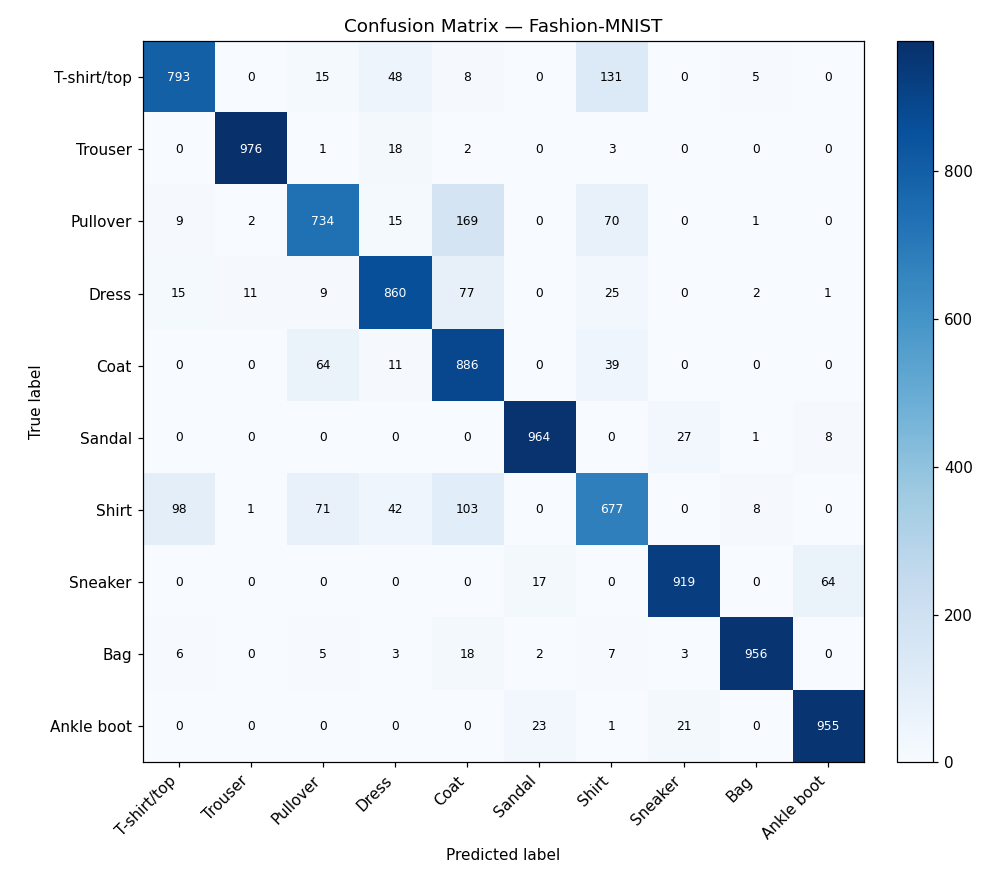

              precision    recall  f1-score   support

 T-shirt/top     0.8610    0.7930    0.8256      1000
     Trouser     0.9859    0.9760    0.9809      1000
    Pullover     0.8165    0.7340    0.7730      1000
       Dress     0.8626    0.8600    0.8613      1000
        Coat     0.7015    0.8860    0.7830      1000
      Sandal     0.9583    0.9640    0.9611      1000
       Shirt     0.7104    0.6770    0.6933      1000
     Sneaker     0.9474    0.9190    0.9330      1000
         Bag     0.9825    0.9560    0.9691      1000
  Ankle boot     0.9290    0.9550    0.9418      1000

    accuracy                         0.8720     10000
   macro avg     0.8755    0.8720    0.8722     10000
weighted avg     0.8755    0.8720    0.8722     10000


In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Training run terpisah, arsitektur sama persis, khusus untuk analisis confusion matrix
cm_model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
cm_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cm_model.fit(fx_train, fy_train, epochs=5, batch_size=32, validation_split=0.2, verbose=2)

cm_loss, cm_acc = cm_model.evaluate(fx_test, fy_test, verbose=0)
print(f"Test accuracy (run ini): {cm_acc:.4f}")

cm_pred = np.argmax(cm_model.predict(fx_test, verbose=0), axis=1)
cm = confusion_matrix(fy_test, cm_pred)

plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Fashion-MNIST")
thresh = cm.max() / 2
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                  color="white" if cm[i, j] > thresh else "black", fontsize=8)
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print(classification_report(fy_test, cm_pred, target_names=class_names, digits=4))

### Yang Kelihatan dari Confusion Matrix

- **Trouser, Bag, Sandal, Ankle boot** — hampir sempurna (recall ≥ 95%). Bentuknya cukup unik jadi jarang ketuker sama kelas lain.
- **Shirt** — kelas paling susah (recall 67.7%). Paling sering ketuker jadi **T-shirt/top** (98 gambar) dan **Coat** (103 gambar).
- **Pullover, Coat, T-shirt/top** — saling ketuker satu sama lain. Pullover ketuker jadi Coat di 169 gambar, Coat ketuker jadi Pullover di 64 gambar.

Ini persis observasi yang saya dapat dari komentar pembaca (Ahmet Ozel) di postingan LinkedIn: bagian atas pakaian (shirt/coat/pullover/t-shirt) punya siluet yang mirip dari sudut pandang grayscale 28×28 pixel, sedangkan Trouser bentuknya unik banget (panjang, sempit) jadi gampang dibedain model. Angka akurasi 87% doang nggak akan pernah nunjukin ini — harus dibedah per kelas.